# Lockbox calibration

Instead of calibrating from the mouse (deformable, imprecise), we calibrate from the rigid **lockbox with known CAD geometry**.

**Workflow:**
1. Load the 2D predictions exported by Notebook 00, pick a lockbox-free frame
2. Manually click 6-10 distinct lockbox points in each view (clicks persist to JSON)
3. Enter their 3D coordinates from the STL/CAD (a one-time task)
4. `cv2.solvePnP` per camera to precise pose, correct scale in mm
5. Validate: reproject the clicked points and visualize the cameras in 3D
6. Save `lockbox_calibration.toml`, then re-triangulate the mouse as a sanity check
7. Optional: bundle-adjustment refinement + reprojection-error stats

**Output:** `lockbox_calibration.toml`, the shared `CameraGroup` reused by every downstream notebook.

## 1. Imports & load state

If `%matplotlib widget` doesn't work: `pip install ipympl` and restart the kernel.

In [1]:
import sys
import cv2
import torch
import zmq

print(sys.executable)
print(cv2.__version__)
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("zmq ok")

/home/kenny/HTCV/.venv/bin/python3
4.11.0
2.3.1+cu121
CUDA: True
zmq ok


In [2]:
%matplotlib notebook

import os, pickle, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import cv2

from aniposelib.cameras import Camera, CameraGroup

warnings.filterwarnings('ignore')

EXPORT_DIR  = Path('../data/pipeline_export/scene1').resolve()
LOCKBOX_OUT = Path('../data/lockbox_calibration/scene1').resolve()
LOCKBOX_OUT.mkdir(parents=True, exist_ok=True)

# Load the 2D state exported by Notebook 00
with open(EXPORT_DIR / '2d_state.pkl', 'rb') as f:
    state = pickle.load(f)

VIEWS = ['top', 'side', 'front']
VIDEO_FOR_VIEW = {k: Path(v) for k, v in state['VIDEO_FOR_VIEW'].items()}
view_predictions = state['view_predictions']
valid_kps = state['valid_kps']
n_frames = min(len(view_predictions[v]) for v in VIEWS)
n_kps = state['n_kps']

for v in VIEWS:
    print(f'  {v}: {VIDEO_FOR_VIEW[v].name}')

  top: 2021-06-18_07-28-45_segment1_mouse291_combined_top-down-view.avi
  side: 2021-06-18_07-28-45_segment1_mouse291_combined_side-view.avi
  front: 2021-06-18_07-28-45_segment1_mouse291_combined_front-view.avi


## 2. Pick a calibration frame

We look for a frame where the **mouse is far from the lockbox center** (i.e. not occluding it). Heuristic: the frame with the fewest detected mouse keypoints in the top view, or the first frames before play begins.

Candidate frames (little mouse in view): [0, 3692, 3693, 3694, 3695, 3696, 3697, 3698, 3699, 3700]


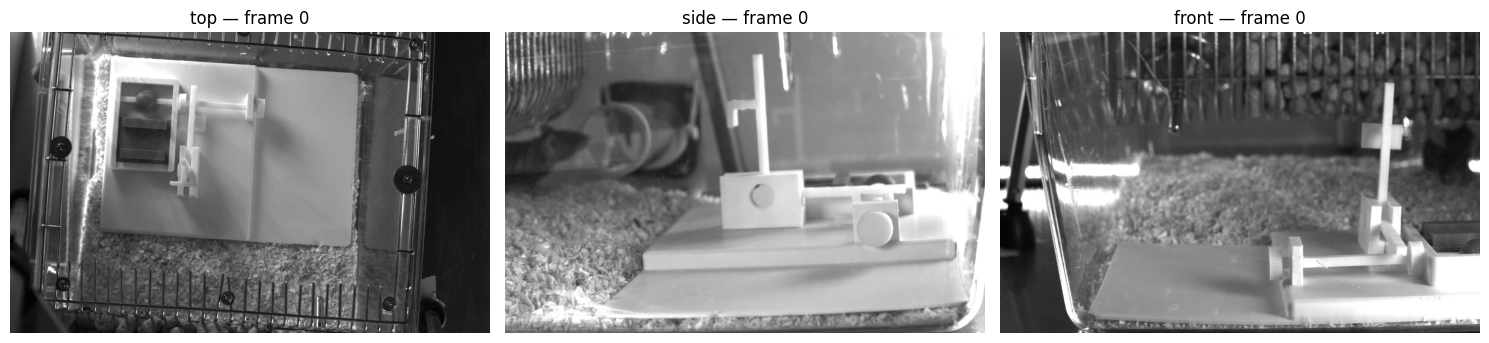

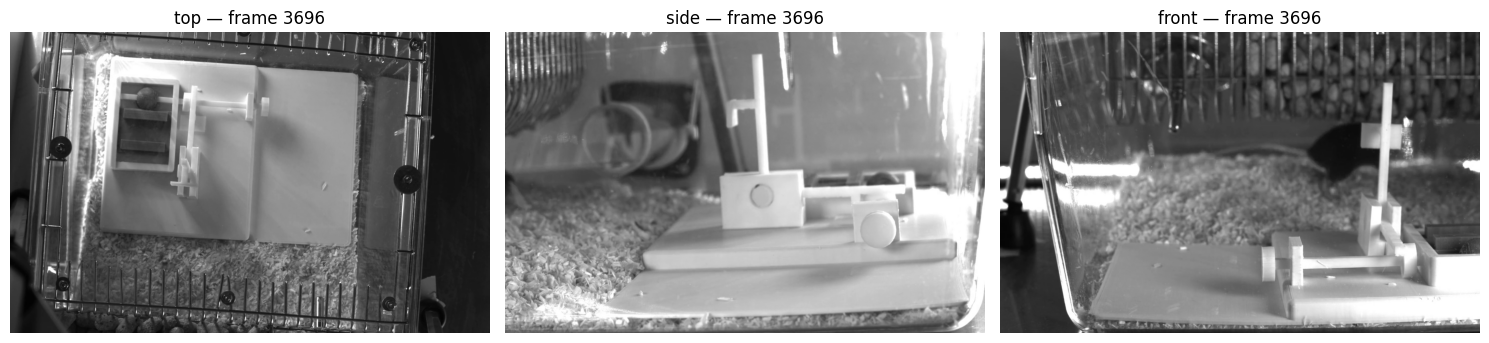

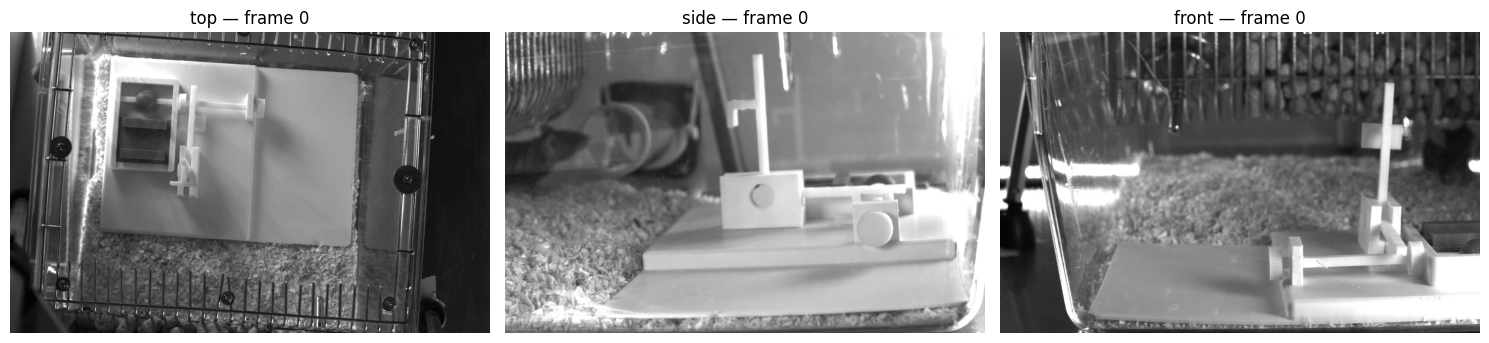

In [3]:
# Heuristic: few mouse detections in the top view -> mouse probably not in the box
df_top = view_predictions['top']
likelihoods_top = df_top.xs('likelihood', axis=1, level=1)
n_detected_per_frame = (likelihoods_top > 0.5).sum(axis=1)

# Best candidates: frames with few mouse detections (mouse away) AND all 3 videos available
candidate_frames = sorted(
    np.argsort(n_detected_per_frame.values)[:20]   # 20 "emptiest" frames
)
print(f'Candidate frames (little mouse in view): {candidate_frames[:10]}')

# Show 3 of them side by side to pick a good one
%matplotlib inline
def show_candidate(frame_idx):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, view in zip(axes, VIEWS):
        cap = cv2.VideoCapture(str(VIDEO_FOR_VIEW[view]))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        cap.release()
        if ok:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{view}  frame {frame_idx}'); ax.axis('off')
    plt.tight_layout(); plt.show()

show_candidate(candidate_frames[0])
show_candidate(candidate_frames[5])
show_candidate(0)   # frame 0 as a fallback

In [ ]:
CALIB_FRAME = 0

# Save frames as PNG (for external inspection and the click tool)
calib_frames = {}
for view in VIEWS:
    cap = cv2.VideoCapture(str(VIDEO_FOR_VIEW[view]))
    cap.set(cv2.CAP_PROP_POS_FRAMES, CALIB_FRAME)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f'Frame {CALIB_FRAME} not readable from {view}')
    out_path = LOCKBOX_OUT / f'calib_frame_{CALIB_FRAME}_{view}.png'
    cv2.imwrite(str(out_path), frame)
    calib_frames[view] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    print(f'Saved {out_path.name}')

Saved calib_frame_0_top.png
Saved calib_frame_0_side.png


Saved calib_frame_0_front.png


## 3. Define the 3D coordinates of the lockbox points

You need **at least 6 points** (for `cv2.solvePnP`), ideally 8-12. Pick distinct, anatomically unambiguous points that are visible in all 3 views:
- Corners of the lockbox base plate
- Tips of mechanisms (stick end, lever handle)
- Prominent edges or corners on the mechanisms

Read the 3D coordinates from:
- **STL files** ([RefinementReferenceCenter/MouseLockBox](https://github.com/RefinementReferenceCenter/MouseLockBox) repo) in Blender/MeshLab
- Or with `trimesh` (see the optional cell below)
- Or by physically measuring the real lockbox

**Important:** Choose an origin (e.g. a corner of the base plate = `(0,0,0)`) and express all other points in **mm** relative to it. The unit doesn't matter as long as it's consistent, the scale of the later 3D mouse tracks follows it.

In [ ]:
POINTS_3D_NAMED = { 
    # Base-plate corners (all at Z=0) 
    #'end_top_right': [ -115.4, -53.88, 1.935],
    #'end_bottom_right': [ -115.4, 79.7, 1.935], 
    'plat_bottom_right': [ -34.38, 79.59, 9.958],
    #'box_corner_right': [24.35, -36.68, 22.84], 
    'out_middle': [-117, 13.04, 2.694],
    # 'out_plat': [-34.54, 13, 11.25],
    'plat_top_right': [ -34.38, -52.89, 9.958], 
    'level_holding_bottom_right': [ 4.101, 52.96, 37],
    'level_holding_top_right': [4.004, 15.43, 36.97],
    'level2_holding_top_right': [ -34.38, -31.41, 27], 
}

POINT_NAMES = list(POINTS_3D_NAMED.keys())
POINTS_3D = np.array([POINTS_3D_NAMED[n] for n in POINT_NAMES], dtype=np.float64)

print(f'{len(POINT_NAMES)} 3D points defined:')
for n, p in zip(POINT_NAMES, POINTS_3D):
    print(f'  {n:<22} ({p[0]:6.1f}, {p[1]:6.1f}, {p[2]:6.1f}) mm')

# Save 3D points as JSON (for reproducibility)
with open(LOCKBOX_OUT / 'points_3d.json', 'w') as f:
    json.dump(POINTS_3D_NAMED, f, indent=2)

6 3D points defined:
  plat_bottom_right      ( -34.4,   79.6,   10.0) mm
  out_middle             (-117.0,   13.0,    2.7) mm
  plat_top_right         ( -34.4,  -52.9,   10.0) mm
  level_holding_bottom_right (   4.1,   53.0,   37.0) mm
  level_holding_top_right (   4.0,   15.4,   37.0) mm
  level2_holding_top_right ( -34.4,  -31.4,   27.0) mm


## 4. Click the 2D points interactively

One cell per view: the image is shown, and you click the points **in the same order as in `POINT_NAMES` above**.

The clicks are saved to JSON. On the next run of the cell they're loaded automatically, so you can pause and continue later.

In [ ]:
import cv2
import numpy as np
import json

POINTS_2D_PATH = LOCKBOX_OUT / 'points_2d.json'

def load_existing_2d():
    if POINTS_2D_PATH.exists():
        with open(POINTS_2D_PATH) as f: return json.load(f)
    return {}

def save_2d(d):
    with open(POINTS_2D_PATH, 'w') as f: json.dump(d, f, indent=2)


def click_points_cv2(view, point_names, img_rgb):
    """OpenCV-based click tool. More reliable than ginput in Jupyter."""
    existing = load_existing_2d()
    if view in existing and len(existing[view]) == len(point_names):
        print(f'->  {view}: already {len(point_names)} points saved.')
        print(f'   To re-click: delete the "{view}" entry in {POINTS_2D_PATH}.')
        return np.array(existing[view])

    base = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    clicks = []

    def redraw():
        d = base.copy()
        for i, (x, y) in enumerate(clicks):
            cv2.circle(d, (int(x), int(y)), 8, (0, 0, 255), 2)
            cv2.circle(d, (int(x), int(y)), 2, (0, 255, 255), -1)
            cv2.putText(d, f'{i+1}', (int(x)+10, int(y)-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        # Show the upcoming point at the bottom
        if len(clicks) < len(point_names):
            txt = f'NEXT ({len(clicks)+1}/{len(point_names)}): {point_names[len(clicks)]}'
            cv2.putText(d, txt, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        else:
            cv2.putText(d, 'DONE  press q to finish', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        return d

    def on_mouse(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and len(clicks) < len(point_names):
            clicks.append((x, y))
            print(f'  {len(clicks)}. {point_names[len(clicks)-1]} -> ({x}, {y})')

    win = f'click points: {view}  [u=undo  r=reset  q/ESC=done]'
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 1400, 900)
    cv2.setMouseCallback(win, on_mouse)

    print(f'\n=== {view} ===  ({len(point_names)} points expected)')
    for i, n in enumerate(point_names):
        print(f'  {i+1}. {n}')
    print('Keys: u=undo, r=reset, q or ESC=done (only when all points are set)')

    while True:
        cv2.imshow(win, redraw())
        key = cv2.waitKey(20) & 0xFF
        if key == ord('u') and clicks:
            removed = clicks.pop()
            print(f'  ↶ undo -> removed ({removed[0]}, {removed[1]})')
        elif key == ord('r'):
            clicks.clear(); print('  ↺ reset')
        elif key in (ord('q'), 27):
            if len(clicks) == len(point_names):
                break
            print(f'Only {len(clicks)}/{len(point_names)} points  keep clicking or reset')

    cv2.destroyWindow(win)
    cv2.waitKey(1)   # make sure the window actually closes (Windows quirk)

    pts = np.array(clicks, dtype=np.float64)
    existing[view] = pts.tolist()
    save_2d(existing)
    print(f'{view}: {len(pts)} points saved')
    return pts


# Click top first
pts_top = click_points_cv2('top', POINT_NAMES, calib_frames['top'])

->  top: already 6 points saved.
   To re-click: delete the "top" entry in /home/kenny/HTCV/data/lockbox_calibration/scene1/points_2d.json.


In [7]:
pts_side = click_points_cv2('side', POINT_NAMES, calib_frames['side'])

->  side: already 6 points saved.
   To re-click: delete the "side" entry in /home/kenny/HTCV/data/lockbox_calibration/scene1/points_2d.json.


In [8]:
pts_front = click_points_cv2('front', POINT_NAMES, calib_frames['front'])

->  front: already 6 points saved.
   To re-click: delete the "front" entry in /home/kenny/HTCV/data/lockbox_calibration/scene1/points_2d.json.


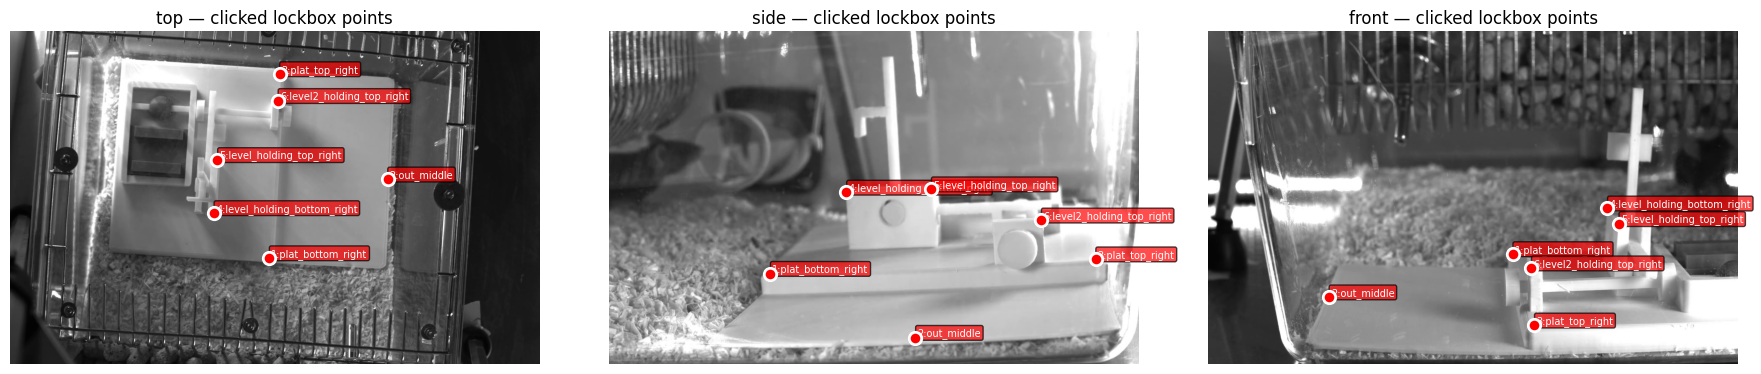

In [9]:
%matplotlib inline

# Clicks as an overlay for visual inspection
POINTS_2D = {'top': pts_top, 'side': pts_side, 'front': pts_front}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, view in zip(axes, VIEWS):
    ax.imshow(calib_frames[view])
    pts = POINTS_2D[view]
    for i, (p, name) in enumerate(zip(pts, POINT_NAMES)):
        ax.scatter(*p, s=80, c='red', edgecolors='white', linewidths=2, zorder=5)
        ax.text(p[0]+8, p[1]-8, f'{i+1}:{name}', fontsize=7,
                color='white', bbox=dict(boxstyle='round,pad=0.2', fc='red', alpha=0.7))
    ax.set_title(f'{view}  clicked lockbox points')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Camera pose per view via solvePnP

In [ ]:
# Video sizes + initial intrinsics
def get_video_size(p):
    cap = cv2.VideoCapture(str(p))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return w, h

video_sizes = {v: get_video_size(VIDEO_FOR_VIEW[v]) for v in VIEWS}

# Basler acA1920-40um with f=25mm lens (per the paper):
# Pixel size of the Basler acA1920-40um = 5.86 μm
# Focal in pixels = focal_mm / pixel_size_mm = 25 / 0.00586 ≈ 4266 px
FOCAL_PX = 25.0 / 0.00586    # ≈ 4266

def make_K(w, h, f=FOCAL_PX):
    return np.array([[f, 0, w/2], [0, f, h/2], [0, 0, 1]], dtype=np.float64)

K = {v: make_K(*video_sizes[v]) for v in VIEWS}
print(f'Initial focal length: {FOCAL_PX:.0f} px (corresponds to a 25mm lens on the Basler)')
for v in VIEWS:
    print(f'  {v}: K =\n{K[v]}')

Initial focal length: 4266 px (corresponds to a 25mm lens on the Basler)
  top: K =
[[4.2662116e+03 0.0000000e+00 9.6800000e+02]
 [0.0000000e+00 4.2662116e+03 6.0800000e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
  side: K =
[[4.2662116e+03 0.0000000e+00 9.6800000e+02]
 [0.0000000e+00 4.2662116e+03 6.0800000e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
  front: K =
[[4.2662116e+03 0.0000000e+00 9.6800000e+02]
 [0.0000000e+00 4.2662116e+03 6.0800000e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]


In [ ]:
# solvePnP per camera
def solve_camera_pose(K_, pts_3d, pts_2d):
    success, rvec, tvec = cv2.solvePnP(
        pts_3d.reshape(-1, 1, 3).astype(np.float64),
        pts_2d.reshape(-1, 1, 2).astype(np.float64),
        K_, np.zeros(5),
        flags=cv2.SOLVEPNP_ITERATIVE,
    )
    return success, rvec.ravel(), tvec.ravel()

cameras_pnp = []
for view in VIEWS:
    ok, rvec, tvec = solve_camera_pose(K[view], POINTS_3D, POINTS_2D[view])
    if not ok:
        print(f'❌ PnP failed for {view}'); continue

    # Reprojection error auf den Calibration-Punkten selbst
    proj, _ = cv2.projectPoints(POINTS_3D, rvec, tvec, K[view], np.zeros(5))
    err = np.linalg.norm(proj.reshape(-1, 2) - POINTS_2D[view], axis=1)
    print(f'{view:<6} | rvec={rvec.round(3)} | tvec=[{tvec[0]:7.1f} {tvec[1]:7.1f} {tvec[2]:7.1f}] mm')
    print(f'         reproj error: median={np.median(err):.2f}px, max={err.max():.2f}px')

    cameras_pnp.append(Camera(
        name=view, size=video_sizes[view],
        matrix=K[view], dist=np.zeros(5),
        rvec=rvec, tvec=tvec,
    ))

cgroup_pnp = CameraGroup(cameras_pnp)
print('\nCameraGroup built')

top    | rvec=[-0.115  3.116 -0.202] | tvec=[  -34.6   -36.7   841.5] mm
         reproj error: median=5.61px, max=10.49px
side   | rvec=[ 1.327 -1.239  0.999] | tvec=[   41.6    32.3   507.6] mm
         reproj error: median=5.24px, max=7.72px
front  | rvec=[1.723 0.008 0.039] | tvec=[   55.6    49.6   481.4] mm
         reproj error: median=5.80px, max=10.99px

CameraGroup built


## 6. Validation: reproject the 3D points

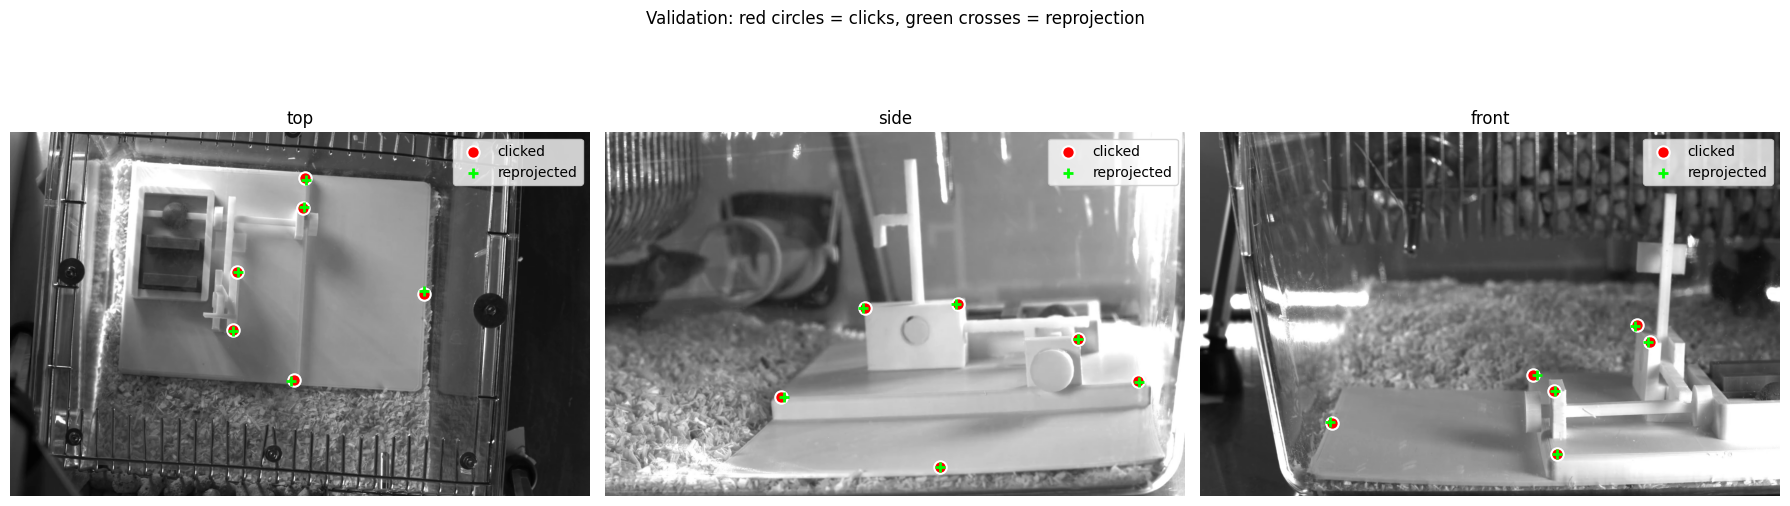

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, view in zip(axes, VIEWS):
    ax.imshow(calib_frames[view])
    # Original clicks in red
    ax.scatter(*POINTS_2D[view].T, s=80, c='red', marker='o',
               edgecolors='white', linewidths=1.5, label='clicked', zorder=5)
    # Reprojection in green
    cam = next(c for c in cgroup_pnp.cameras if c.get_name() == view)
    proj, _ = cv2.projectPoints(POINTS_3D, cam.rvec, cam.tvec, cam.matrix, cam.dist)
    proj = proj.reshape(-1, 2)
    ax.scatter(*proj.T, s=60, c='lime', marker='+', linewidths=2,
               label='reprojected', zorder=6)
    for p, pp in zip(POINTS_2D[view], proj):
        ax.plot([p[0], pp[0]], [p[1], pp[1]], '-', c='yellow', lw=0.8, alpha=0.8)
    ax.set_title(f'{view}')
    ax.axis('off'); ax.legend()
plt.suptitle('Validation: red circles = clicks, green crosses = reprojection')
plt.tight_layout(); plt.show()

## 7. Visualize the cameras in 3D

The cameras should now be arranged geometrically plausibly around the lockbox.

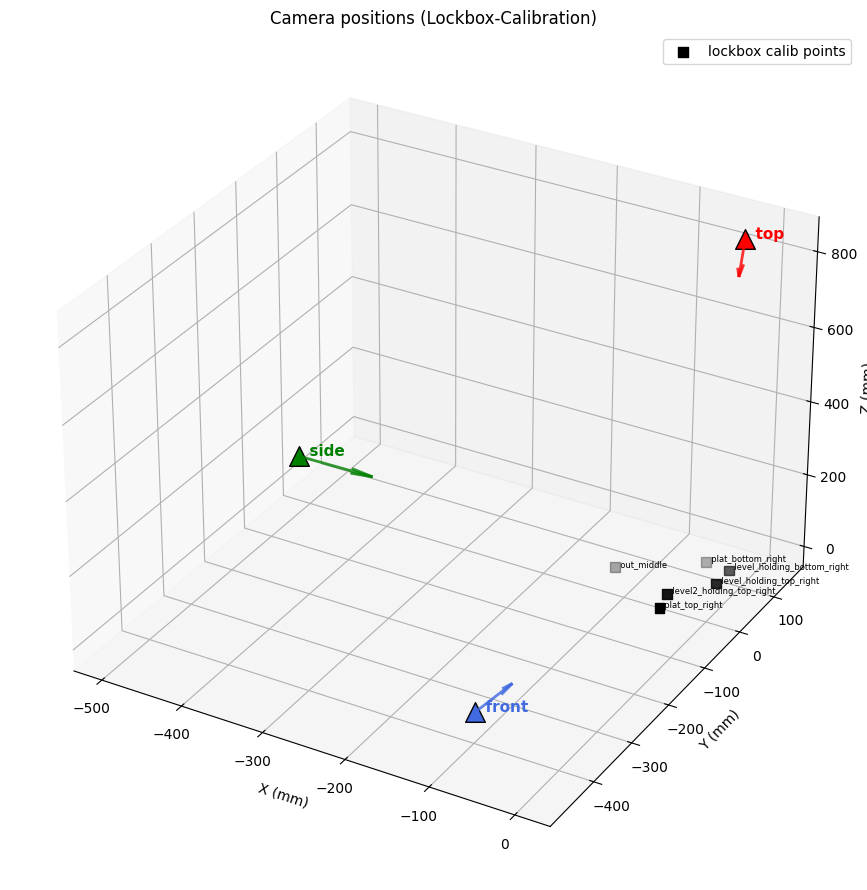

In [13]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D calibration points
ax.scatter(*POINTS_3D.T, s=50, c='black', marker='s', label='lockbox calib points')
for name, p in POINTS_3D_NAMED.items():
    ax.text(p[0], p[1], p[2], f'  {name}', fontsize=6)

# Cameras
colors = {'top': 'red', 'side': 'green', 'front': 'royalblue'}
arrow_len = max(POINTS_3D.std(axis=0)) * 2

for cam in cgroup_pnp.cameras:
    name = cam.get_name()
    R, _ = cv2.Rodrigues(cam.rvec)
    C = (-R.T @ cam.tvec.reshape(3, 1)).ravel()
    forward = R.T @ np.array([0, 0, 1.0])

    ax.scatter(*C, s=200, c=colors[name], marker='^', edgecolors='k', zorder=5)
    ax.quiver(*C, *(forward * arrow_len), color=colors[name], alpha=0.8, lw=2)
    ax.text(*C, f'  {name}', fontsize=11, color=colors[name], weight='bold')

ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
ax.set_title('Camera positions (Lockbox-Calibration)')
ax.legend()
plt.tight_layout(); plt.show()

## 8. Save and re-triangulate the mouse tracks with the new calibration

In [ ]:
# Save calibration
cgroup_pnp.dump(str(LOCKBOX_OUT / 'lockbox_calibration.toml'))
print(f'Saved -> {LOCKBOX_OUT / "lockbox_calibration.toml"}')

# Load the old 2D points (for the mouse) from the main notebook state
# state['view_predictions'] already has them  we rebuild the points_2d array
from copy import deepcopy

view_order = ['top', 'side', 'front']
CONF_3D = 0.5

# We need KEYPOINT_MAP  reconstruct if it isn't in state
if 'KEYPOINT_MAP' in state:
    KEYPOINT_MAP = state['KEYPOINT_MAP']
else:
    # If it wasn't saved: deriving it from valid_kps and view_predictions is hard.
    # Instead: only triangulate keypoints that share the same name across all 3 views.
    raise RuntimeError("KEYPOINT_MAP missing from state.")

points_2d = np.full((3, n_frames, n_kps, 2), np.nan, dtype=np.float64)
for c, view in enumerate(view_order):
    df = view_predictions[view]
    for k, canon in enumerate(valid_kps):
        bp = KEYPOINT_MAP[canon][c]
        if bp is None or bp not in df.columns.get_level_values(0): continue
        x = df[bp]['x'].values[:n_frames]
        y = df[bp]['y'].values[:n_frames]
        l = df[bp]['likelihood'].values[:n_frames]
        mask = l > CONF_3D
        points_2d[c, mask, k, 0] = x[mask]
        points_2d[c, mask, k, 1] = y[mask]

Saved -> /home/kenny/HTCV/data/lockbox_calibration/scene1/lockbox_calibration.toml


In [15]:
# Re-triangulate with the new calibration
points_3d_new = np.full((n_frames, n_kps, 3), np.nan, dtype=np.float64)

for f in range(n_frames):
    fp = points_2d[:, f, :, :]
    n_views = (~np.isnan(fp[..., 0])).sum(axis=0)
    mask = n_views >= 2
    if not mask.any(): continue
    points_3d_new[f, mask] = cgroup_pnp.triangulate(fp[:, mask, :], undistort=True)

n_valid_new = np.isfinite(points_3d_new).all(axis=-1).sum(axis=1)

print(f'Lockbox calibration: {n_valid_new.mean():.1f} kp/frame triangulated')

# In mm now  length measurement
tail_idx = valid_kps.index('tail_base') if 'tail_base' in valid_kps else None
nose_idx = valid_kps.index('nose')      if 'nose'      in valid_kps else None
if tail_idx is not None and nose_idx is not None:
    diffs = points_3d_new[:, tail_idx] - points_3d_new[:, nose_idx]
    lengths = np.linalg.norm(diffs, axis=-1)
    lengths = lengths[np.isfinite(lengths)]
    print(f'\nMouse length (nose->tail_base): median {np.median(lengths):.1f} mm')
    print(f'   (sanity check: an adult mouse is ~70–100 mm head-to-rump)')

Lockbox calibration: 2.9 kp/frame triangulated

Mouse length (nose->tail_base): median 62.4 mm
   (sanity check: an adult mouse is ~70–100 mm head-to-rump)


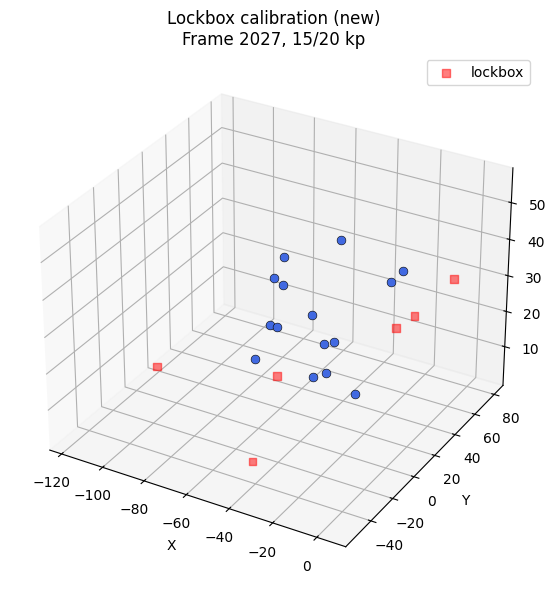

In [16]:
# Plot the lockbox-calibrated mouse reconstruction on the best-covered frame
best = int(np.argmax(n_valid_new))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
pts = points_3d_new[best]
for k, name in enumerate(valid_kps):
    if np.isfinite(pts[k]).all():
        ax.scatter(*pts[k], s=40, c='royalblue', edgecolors='k', lw=0.4)
# Lockbox calibration points as reference
ax.scatter(*POINTS_3D.T, s=30, c='red', marker='s', alpha=0.5, label='lockbox')
ax.legend()
ax.set_title(f'Lockbox calibration (new)\nFrame {best}, {np.isfinite(pts).all(axis=1).sum()}/{n_kps} kp')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.tight_layout(); plt.show()

In [ ]:
# Optional: bundle adjustment with mouse points for refinement
# Caution: BA can also degrade the nice lockbox calibration again,
# if the mouse correspondences are poor. Start with small n_iters.

DO_BA_REFINE = True

if DO_BA_REFINE:
    stride = 5
    pts_ba = points_2d[:, ::stride].reshape(3, -1, 2)
    err_before = cgroup_pnp.average_error(pts_ba, median=True)
    print(f'Reproj err BEFORE BA refine: {err_before:.2f} px')
    cgroup_pnp.bundle_adjust_iter(pts_ba, n_iters=3, ftol=1e-4, verbose=True)
    err_after = cgroup_pnp.average_error(pts_ba, median=True)
    print(f'Reproj err AFTER BA refine:  {err_after:.2f} px')

Reproj err BEFORE BA refine: nan px


error:  19.203089084900792
n_samples: 200
{(0, 1): (1000, array([10.88731783, 38.5581146 ])),
 (0, 2): (1000, array([ 8.90197091, 33.75487824])),
 (1, 2): (1000, array([ 9.89258284, 41.40111749]))}
error: 19.34, mu: 15.0, ratio: 0.374


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.5181e+04                                    3.17e+05    
       1              2         2.7349e+04      1.78e+04       4.16e+02       1.26e+04    
       2              3         2.7269e+04      7.95e+01       7.16e+01       3.09e+02    
       3              4         2.7269e+04      9.40e-02       4.34e-01       1.04e+01    
`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 4.5181e+04, final cost 2.7269e+04, first-order optimality 1.04e+01.
{(0, 1): (1000, array([ 6.79434175, 36.60088037])),
 (0, 2): (1000, array([ 6.88679   , 33.17281559])),
 (1, 2): (1000, array([ 8.4371503 , 42.02255802]))}
error: 16.71, mu: 8.4, ratio: 0.264


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2173e+04                                    1.31e+05    
       1              2         8.8684e+03      3.30e+03       4.59e+02       2.11e+04    
       2              3         8.7427e+03      1.26e+02       2.04e+02       5.42e+03    
       3              4         8.7382e+03      4.56e+00       7.22e-01       2.51e+00    
       4              5         8.7382e+03      2.22e-03       1.47e+00       9.55e+00    
`ftol` termination condition is satisfied.
Function evaluations 5, initial cost 1.2173e+04, final cost 8.7382e+03, first-order optimality 9.55e+00.
{(0, 1): (1000, array([ 6.07859365, 36.57352016])),
 (0, 2): (1000, array([ 6.49224263, 32.72212826])),
 (1, 2): (1000, array([ 6.80909388, 39.92816351]))}
error: 15.92, mu: 6.8, ratio: 0.239


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.5768e+03                                    1.89e+04    
       1              2         5.5503e+03      1.03e+03       7.28e+02       5.09e+04    
       2              3         5.3483e+03      2.02e+02       1.84e+02       3.16e+03    
       3              4         5.3467e+03      1.62e+00       4.87e-01       1.33e+00    
       4              5         5.3467e+03      1.84e-04       1.33e-01       9.48e+00    
`ftol` termination condition is satisfied.
Function evaluations 5, initial cost 6.5768e+03, final cost 5.3467e+03, first-order optimality 9.48e+00.


{(0, 1): (1000, array([ 5.60511318, 35.44468463])),
 (0, 2): (1000, array([ 5.9009831 , 33.09628194])),
 (1, 2): (1000, array([ 7.15863098, 41.11330787]))}


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.1609e+05                                    7.74e+05    
       1              2         5.1166e+05      1.04e+05       6.96e+02       3.80e+05    
       2              3         5.0647e+05      5.20e+03       4.96e+01       5.00e+03    


       3              4         5.0646e+05      1.31e+01       7.48e+00       4.46e+02    
`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 6.1609e+05, final cost 5.0646e+05, first-order optimality 4.46e+02.
{(0, 1): (1000, array([ 6.06784467, 34.57039925])),
 (0, 2): (1000, array([ 6.16470048, 31.56088679])),
 (1, 2): (1000, array([ 7.50356424, 40.23464125]))}
error:  14.743913635757966
Reproj err AFTER BA refine:  nan px


In [18]:
def reproj_error_manual(cgroup, points_2d):
    """Per-observation reprojection error, NaN-safe."""
    n_cams, n_pts, _ = points_2d.shape
    visible_count = (~np.isnan(points_2d[..., 0])).sum(axis=0)
    triangulable = visible_count >= 2
    if not triangulable.any():
        return np.array([])

    pts_3d = cgroup.triangulate(points_2d[:, triangulable], undistort=True)
    proj = cgroup.project(pts_3d)                  # (n_cams, n_tri, 2)

    errors = []
    pts_in = points_2d[:, triangulable, :]
    for c in range(n_cams):
        valid = ~np.isnan(pts_in[c, :, 0])
        diff = proj[c, valid] - pts_in[c, valid]
        errors.append(np.linalg.norm(diff, axis=-1))
    return np.concatenate(errors)

errs = reproj_error_manual(cgroup_pnp, pts_ba)
print(f'Number of observations: {len(errs)}')
print(f'Median: {np.median(errs):6.2f} px')
print(f'P75:    {np.percentile(errs, 75):6.2f} px')
print(f'P95:    {np.percentile(errs, 95):6.2f} px')

Number of observations: 10127
Median:  11.90 px
P75:     26.42 px
P95:     61.42 px
